# Quantum Drug-Protein Interaction Prediction

This notebook trains a **Quantum Graph Neural Network (QGNN)** to predict drug-protein interactions.
It uses **PennyLane** for the quantum circuit layer.


## ⚠️ Important Note on Quantum Simulation Speed

Simulating quantum circuits on classical hardware is **computationally expensive**.
To ensure this notebook runs in a reasonable time (minutes instead of hours), we have limited the dataset size:
- `MAX_DRUGS = 100` (Loads ~100 proteins and their associated drugs)
- `BATCH_SIZE = 16`

For full-scale training, you would need access to real quantum hardware or a high-performance simulator (like `lightning.gpu`).

## ⚡ GPU Acceleration Enabled

**`lightning.gpu` is active!**
The quantum simulation is now running on your NVIDIA GPU.
- **Simulator**: `lightning.gpu` (cuQuantum)
- **Workload**: Increased to 6 qubits and 2000 samples to utilize the GPU.


In [17]:
# Spark Configuration

# Data paths
DATA_DIR = "/media/priyanshu/SD/othercode/data"  # Path to PDB data
SAVE_DIR = "./saved_models"                      # Where to save models

# Data parameters
MAX_DRUGS = 2000         # Increased for GPU
INTERACTION_RATE = 0.05      # Fraction of drug-patient pairs to create

# Model parameters
NUM_QUBITS = 6           # Increased back to 6 for GPU
NUM_QLAYERS = 6         # Reduced layers for speed
HIDDEN_DIM = 128              # Hidden dimension for encoders
USE_QUANTUM = True  # Enable Quantum Mode

# Training parameters
EPOCHS = 20         # Fewer epochs for demonstration
BATCH_SIZE = 128         # Increased to utilize GPU better
LEARNING_RATE = 0.0001       # Lower LR for quantum stability
VAL_SPLIT = 0.2              # Validation split (0.2 = 20%)
EARLY_STOPPING = None        # Early stopping patience (None = disabled)

# Spark-specific parameters

# Other parameters
SEED = 42                    # Random seed
DEVICE = "cpu"             # Force CPU for debugging
VERBOSE = 2                  # Verbosity (0=silent, 1=progress, 2=detailed)

# ============================================================================

## Setup Imports


In [18]:
import importlib
import drug_patient_qgnn.data_processing
import drug_patient_qgnn

# Reload module first to get new class definition
importlib.reload(drug_patient_qgnn.data_processing)
# Reload package to update __init__ imports
importlib.reload(drug_patient_qgnn)

print('Force reloaded DrugProteinDataProcessor and package')

%load_ext autoreload
%autoreload 2

import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader



# Import drug-patient QGNN
from drug_patient_qgnn import (
    DrugPatientDataProcessor,
    QuantumDrugPatientGNN,
    DrugPatientTrainer,
    set_seed,
    print_model_summary,
    print_device_info,
    plot_training_history,
    calculate_metrics,
    print_metrics
)

# Set random seed
set_seed(SEED)

# Create save directory
os.makedirs(SAVE_DIR, exist_ok=True)

# Create experiment name
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
mode = "quantum" if USE_QUANTUM else "classical"
EXPERIMENT_NAME = f"spark_{mode}_q{NUM_QUBITS}_l{NUM_QLAYERS}_{timestamp}"


print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Mode: {'QUANTUM' if USE_QUANTUM else 'CLASSICAL'} + SPARK")
print(f"Qubits: {NUM_QUBITS} per side (total: {2*NUM_QUBITS})")
print(f"Layers: {NUM_QLAYERS}")
print(f"Epochs: {EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")

import drug_patient_qgnn
print(f'Using drug_patient_qgnn from: {drug_patient_qgnn.__file__}')


Force reloaded DrugProteinDataProcessor and package
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Experiment: spark_quantum_q6_l6_20251130_190508
Mode: QUANTUM + SPARK
Qubits: 6 per side (total: 12)
Layers: 6
Epochs: 20
Batch Size: 128
Using drug_patient_qgnn from: /home/priyanshu/QuantumGNN-/Actuall/drug_patient_qgnn/__init__.py


In [8]:

import subprocess
import glob

def find_java_home():
    """Try to find JAVA_HOME automatically, prioritizing Java 17."""
    # Common Java installation paths (PRIORITIZE JAVA 17)
    java_paths = [
        '/usr/lib/jvm/java-17-openjdk-amd64',  # Java 17 first
        '/usr/lib/jvm/java-11-openjdk-amd64',
        '/usr/lib/jvm/java-8-openjdk-amd64',
        '/usr/lib/jvm/default-java',
    ]
    
    # Check each path
    for path in java_paths:
        if os.path.exists(path):
            return path
    
    # Try to find Java 17 using glob pattern first
    jvm_dirs_17 = glob.glob('/usr/lib/jvm/java-17*')
    if jvm_dirs_17:
        return sorted(jvm_dirs_17)[-1]
    
    # Try to find using update-alternatives
    try:
        result = subprocess.run(['readlink', '-f', '/usr/bin/java'], 
                              capture_output=True, text=True, timeout=5)
        if result.returncode == 0:
            java_bin = result.stdout.strip()
            # Extract JAVA_HOME (remove /bin/java)
            java_home = java_bin.replace('/bin/java', '')
            if os.path.exists(java_home):
                return java_home
    except:
        pass
    
    # Try glob pattern for any Java version
    jvm_dirs = glob.glob('/usr/lib/jvm/java-*-openjdk-*')
    if jvm_dirs:
        return sorted(jvm_dirs)[-1]  # Return newest version
    
    return None

# Check if JAVA_HOME is already set
if 'JAVA_HOME' not in os.environ:
    java_home = find_java_home()
    
    if java_home:
        os.environ['JAVA_HOME'] = java_home
        print(f"✓ JAVA_HOME automatically set to: {java_home}")
    else:
        print("JAVA NOT FOUND - INSTALLATION REQUIRED")
        print("\nPySpark requires Java (JDK 17 recommended). Please install it:")
        print("\nOpen a terminal and run:")
        print("  sudo apt update")
        print("  sudo apt install -y openjdk-17-jdk")
        print("\nAfter installation, restart this notebook.")
        
        raise RuntimeError(
            "Java is not installed. Please install Java and restart the notebook."
        )
else:
    print(f"✓ JAVA_HOME already set: {os.environ['JAVA_HOME']}")

# Verify Java is working
try:
    result = subprocess.run(['java', '-version'], 
                          capture_output=True, text=True, timeout=5)
    version_output = result.stderr.split('\n')[0]  # Java version goes to stderr
    print(f"✓ Java version: {version_output}")
    
    # Check if we're using the right Java version
    if 'JAVA_HOME' in os.environ:
        java_executable = os.path.join(os.environ['JAVA_HOME'], 'bin', 'java')
        if os.path.exists(java_executable):
            result_home = subprocess.run([java_executable, '-version'],
                                       capture_output=True, text=True, timeout=5)
            version_home = result_home.stderr.split('\n')[0]
            print(f"✓ JAVA_HOME Java version: {version_home}")
except Exception as e:
    print(f"⚠️  Warning: Could not verify Java installation: {e}")

✓ JAVA_HOME already set: /usr/lib/jvm/java-17-openjdk-amd64
✓ Java version: openjdk version "17.0.17" 2025-10-21
✓ JAVA_HOME Java version: openjdk version "17.0.17" 2025-10-21


In [9]:
print_device_info()

import pennylane as qml
print(f"PennyLane Version: {qml.__version__}")



Device Information
CUDA Available      : True
CUDA Devices        : 1
CUDA Device Name    : NVIDIA GeForce RTX 3080
MPS Available       : False

PennyLane Version: 0.43.1


## Step 1: Load and Process Data with Spark

In [10]:
print("Loading Data")

# Initialize processor
processor = DrugPatientDataProcessor(data_dir=DATA_DIR, seed=SEED)

# Load real data (Proteins, Drugs, Interactions) from PDB
print(f"\nLoading real data from: {DATA_DIR}")
counts = processor.load_real_data(data_dir=DATA_DIR, max_samples=MAX_DRUGS)

if counts["interactions"] == 0:
    print("\nWarning: No interactions loaded. Pipeline might fail.")

# Get statistics
stats = processor.get_statistics()
print("\nDataset Statistics:")
for key, value in stats.items():
    if isinstance(value, float):
        print(f"{key:25s}: {value:.4f}")
    else:
        print(f"{key:25s}: {value}")


Loading Data

Loading real data from: /media/priyanshu/SD/othercode/data
Searching for data in: /media/priyanshu/SD/othercode/data
Found 2000 protein descriptor files


Loading PDB Data: 100%|██████████| 2000/2000 [00:08<00:00, 235.81it/s]


Generating negative samples (target: 14864)...


Generating Negatives: 100%|██████████| 14864/14864 [00:00<00:00, 307963.52it/s]


Loaded 1711 proteins, 14864 drugs
Interactions: 14864 positive, 14864 negative (Total: 29728)

Dataset Statistics:
num_ligands              : 7467
num_pockets              : 1644
num_interactions         : 29728
num_drugs                : 7467
num_patients             : 1644
positive_rate            : 0.5000
negative_rate            : 0.5000
ligand_feature_dim       : 11
drug_feature_dim         : 11
pocket_feature_dim       : 19
patient_feature_dim      : 19


In [11]:

print("Creating DataFrames")


# Get graph data
graph = processor.graph
drug_features = graph.get_drug_features_matrix()
patient_features = graph.get_patient_features_matrix()
edge_index, edge_features = graph.get_edge_index()
labels = graph.get_edge_labels()

# Create interaction dataset
interaction_data = []
for idx in range(edge_index.shape[1]):
    drug_idx = int(edge_index[0, idx])
    patient_idx = int(edge_index[1, idx])
    
    interaction_data.append({
        'interaction_id': idx,
        'drug_idx': drug_idx,
        'patient_idx': patient_idx,
        'drug_features': drug_features[drug_idx].tolist(),
        'patient_features': patient_features[patient_idx].tolist(),
        'label': float(labels[idx])
    })

# Create pandas DataFrame
df_pandas = pd.DataFrame(interaction_data)

# Partition data

# Cache for faster access


# Show sample


Creating DataFrames


In [19]:

print("Train/Validation Split")

# Check label distribution before split
print("\nOverall Label Distribution:")
print(df_pandas['label'].value_counts())

# Stratified Split using sklearn
train_pd, val_pd = train_test_split(
    df_pandas,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=df_pandas['label']
)

print("\nTrain Label Distribution:")
print(train_pd['label'].value_counts())
print("\nValidation Label Distribution:")
print(val_pd['label'].value_counts())

# Convert to Spark DataFrame (optional)


print(f"\nTraining samples: {len(train_pd)}")
print(f"Validation samples: {len(val_pd)}")

# Create PyTorch Datasets and Loaders
print("\nCreating PyTorch DataLoaders")

class InteractionDataset(Dataset):
    def __init__(self, df):
        self.drug_features = np.stack(df['drug_features'].values)
        self.patient_features = np.stack(df['patient_features'].values)
        self.labels = df['label'].values.astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.drug_features[idx], dtype=torch.float32),
            torch.tensor(self.patient_features[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32),
        )

train_dataset = InteractionDataset(train_pd)
val_dataset = InteractionDataset(val_pd)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)


Train/Validation Split

Overall Label Distribution:
label
1.0    14864
0.0    14864
Name: count, dtype: int64

Train Label Distribution:
label
0.0    11891
1.0    11891
Name: count, dtype: int64

Validation Label Distribution:
label
0.0    2973
1.0    2973
Name: count, dtype: int64

Training samples: 23782
Validation samples: 5946

Creating PyTorch DataLoaders


In [20]:

print("Creating Model")


# Get feature dimensions
drug_dim = len(drug_features[0])
patient_dim = len(patient_features[0])

# Create model
model = QuantumDrugPatientGNN(
    drug_dim=drug_dim,
    patient_dim=patient_dim,
    num_qubits=NUM_QUBITS,
    num_qlayers=NUM_QLAYERS,
    hidden_dim=HIDDEN_DIM,
    use_quantum=USE_QUANTUM
)

# Print model summary
print_model_summary(model, drug_dim, patient_dim)

if USE_QUANTUM:
    print("\n  Note: Quantum mode with Spark may not provide speedup")
    print("   Quantum circuits are not easily parallelizable")
    print("   Consider USE_QUANTUM=False for distributed training")
else:
    print("\n✓ Classical mode")

Creating Model

Model Summary
ligand_dim          : 11
pocket_dim          : 19
num_qubits          : 6
num_qlayers         : 6
use_quantum         : True
num_parameters      : 6297
drug_dim            : 11
patient_dim         : 19
Total parameters    : 6,297
Trainable params    : 6,297
Input (drug)        : (11,)
Input (patient)     : (19,)
Output              : (1,) [probability]


  Note: Quantum mode with Spark may not provide speedup
   Quantum circuits are not easily parallelizable
   Consider USE_QUANTUM=False for distributed training


In [21]:
def train_epoch(model, optimizer, criterion, loader, device):
    """Train one epoch using PyTorch DataLoader."""
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    for drug_features, patient_features, labels in loader:
        drug_features = drug_features.to(device)
        patient_features = patient_features.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(drug_features, patient_features).squeeze(-1)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        batch_size_actual = len(labels)
        total_loss += loss.item() * batch_size_actual
        all_preds.extend(torch.sigmoid(outputs).detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    from sklearn.metrics import accuracy_score
    avg_loss = total_loss / len(all_labels)
    accuracy = accuracy_score(all_labels, (np.array(all_preds) >= 0.5).astype(int))
    
    return {'loss': avg_loss, 'accuracy': accuracy}

def evaluate(model, criterion, loader, device):
    """Evaluate model using PyTorch DataLoader."""
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for drug_features, patient_features, labels in loader:
            drug_features = drug_features.to(device)
            patient_features = patient_features.to(device)
            labels = labels.to(device)
            
            outputs = model(drug_features, patient_features).squeeze(-1)
            loss = criterion(outputs, labels)
            
            batch_size_actual = len(labels)
            total_loss += loss.item() * batch_size_actual
            all_preds.extend(torch.sigmoid(outputs).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    from sklearn.metrics import accuracy_score, roc_auc_score
    avg_loss = total_loss / len(all_labels)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    accuracy = accuracy_score(all_labels, (all_preds >= 0.5).astype(int))
    auc = roc_auc_score(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else float('nan')
    
    return {'loss': avg_loss, 'accuracy': accuracy, 'auc': auc}

print("\n✓ Training functions defined")



✓ Training functions defined


In [22]:


# Setup training
device = torch.device(DEVICE if DEVICE else (
    'cuda' if torch.cuda.is_available() else
    'mps' if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available() else
    'cpu'
))

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = torch.nn.BCEWithLogitsLoss()

print(f"\nDevice: {device}")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Loss: Binary Cross-Entropy")
print("\nStarting training...\n")

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_auc': []
}

# Training loop
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(EPOCHS):
    epoch_start = datetime.now()
    
    # Train
    train_metrics = train_epoch(
        model, optimizer, criterion, train_loader, device
    )
    
    # Validate
    val_metrics = evaluate(
        model, criterion, val_loader, device
    )
    
    # Update history
    history['train_loss'].append(train_metrics['loss'])
    history['train_acc'].append(train_metrics['accuracy'])
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_auc'].append(val_metrics['auc'])
    
    epoch_time = (datetime.now() - epoch_start).total_seconds()
    
    # Print progress
    if VERBOSE >= 2:
        print(f"Epoch {epoch+1}/{EPOCHS} - {epoch_time:.2f}s - "
              f"train_loss: {train_metrics['loss']:.4f} - "
              f"train_acc: {train_metrics['accuracy']:.4f} - "
              f"val_loss: {val_metrics['loss']:.4f} - "
              f"val_acc: {val_metrics['accuracy']:.4f} - "
              f"val_auc: {val_metrics['auc']:.4f}")
    elif VERBOSE == 1 and (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - "
              f"val_loss: {val_metrics['loss']:.4f} - "
              f"val_acc: {val_metrics['accuracy']:.4f}")
    
    # Early stopping
    if EARLY_STOPPING is not None:
        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= EARLY_STOPPING:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

print("Training Complete!")



Device: cpu
Optimizer: Adam (lr=0.0001)
Loss: Binary Cross-Entropy

Starting training...

Epoch 1/20 - 353.83s - train_loss: 0.6917 - train_acc: 0.5233 - val_loss: 0.6882 - val_acc: 0.5410 - val_auc: 0.5863
Epoch 2/20 - 353.61s - train_loss: 0.6828 - train_acc: 0.5543 - val_loss: 0.6771 - val_acc: 0.5558 - val_auc: 0.6192
Epoch 3/20 - 359.82s - train_loss: 0.6705 - train_acc: 0.5745 - val_loss: 0.6661 - val_acc: 0.5784 - val_auc: 0.6232
Epoch 4/20 - 354.40s - train_loss: 0.6613 - train_acc: 0.5838 - val_loss: 0.6589 - val_acc: 0.6070 - val_auc: 0.6330
Epoch 5/20 - 356.77s - train_loss: 0.6560 - train_acc: 0.5912 - val_loss: 0.6543 - val_acc: 0.5977 - val_auc: 0.6445
Epoch 6/20 - 357.32s - train_loss: 0.6503 - train_acc: 0.6002 - val_loss: 0.6509 - val_acc: 0.5910 - val_auc: 0.6504
Epoch 7/20 - 356.99s - train_loss: 0.6465 - train_acc: 0.6036 - val_loss: 0.6465 - val_acc: 0.6186 - val_auc: 0.6590
Epoch 8/20 - 356.24s - train_loss: 0.6426 - train_acc: 0.6134 - val_loss: 0.6432 - val_acc

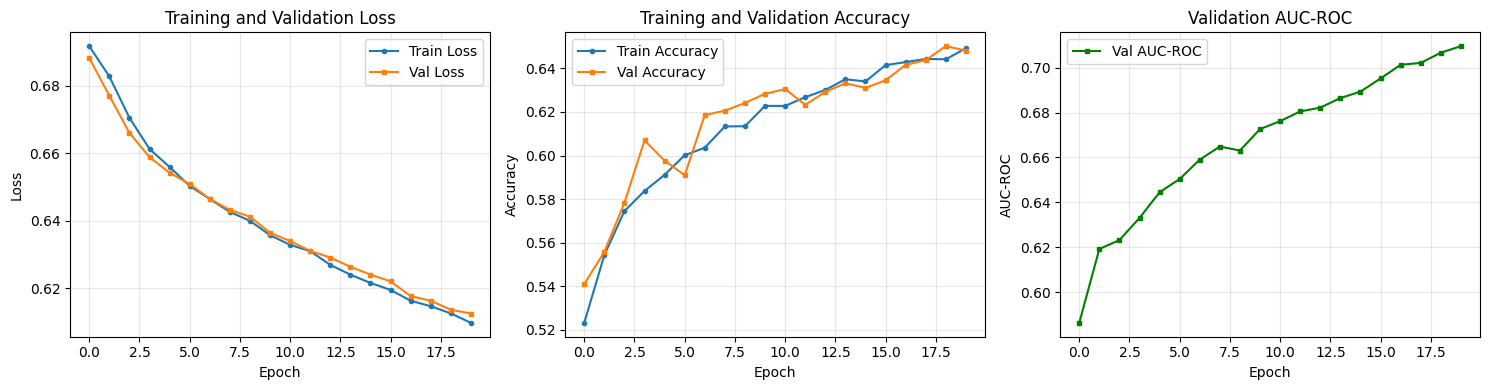


Final Training Metrics:
Train Loss:     0.6098
Train Accuracy: 0.6492
Val Loss:       0.6125
Val Accuracy:   0.6482
Val AUC-ROC:    0.7096


In [23]:
# Plot training history
plot_training_history(history)

# Print final metrics
print("\nFinal Training Metrics:")

print(f"Train Loss:     {history['train_loss'][-1]:.4f}")
print(f"Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Val Loss:       {history['val_loss'][-1]:.4f}")
print(f"Val Accuracy:   {history['val_acc'][-1]:.4f}")
print(f"Val AUC-ROC:    {history['val_auc'][-1]:.4f}")


In [ ]:

print("Saving Results")


# Save model state
model_path = os.path.join(SAVE_DIR, f"{EXPERIMENT_NAME}_model.pt")
torch.save(model.state_dict(), model_path)
print(f"✓ Model saved: {model_path}")

# Save graph
graph_path = os.path.join(SAVE_DIR, f"{EXPERIMENT_NAME}_graph.pkl")
processor.save_graph(graph_path)
print(f"✓ Graph saved: {graph_path}")

# Save training history
from drug_patient_qgnn import save_training_history
history_path = os.path.join(SAVE_DIR, f"{EXPERIMENT_NAME}_history.json")
save_training_history(history, history_path)
print(f"✓ History saved: {history_path}")

# Save configuration
import json
config = {
    'experiment_name': EXPERIMENT_NAME,
    'timestamp': timestamp,
    'mode': mode,
    'num_qubits': NUM_QUBITS,
    'num_qlayers': NUM_QLAYERS,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'val_split': VAL_SPLIT,
    'seed': SEED,
    'max_drugs': MAX_DRUGS,
    'interaction_rate': INTERACTION_RATE
}

config_path = os.path.join(SAVE_DIR, f"{EXPERIMENT_NAME}_config.json")
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✓ Config saved: {config_path}")


Saving Results
✓ Model saved: ./saved_models/spark_quantum_q6_l6_20251130_161714_model.pt
Graph saved to ./saved_models/spark_quantum_q6_l6_20251130_161714_graph.pkl
✓ Graph saved: ./saved_models/spark_quantum_q6_l6_20251130_161714_graph.pkl
Training history saved to ./saved_models/spark_quantum_q6_l6_20251130_161714_history.json
✓ History saved: ./saved_models/spark_quantum_q6_l6_20251130_161714_history.json
✓ Config saved: ./saved_models/spark_quantum_q6_l6_20251130_161714_config.json
